# Task 2: Empirical Diagnostic of Custom Weight Initializations and Gradient Vanishing

In [1]:
import torch, math, numpy as np, matplotlib.pyplot as plt
torch.manual_seed(42)


In [2]:
def xavier_init(w):
    fan_in,fan_out=w.shape[1],w.shape[0]
    limit=math.sqrt(6/(fan_in+fan_out))
    with torch.no_grad(): w.uniform_(-limit,limit)
def he_init(w):
    fan_in=w.shape[1]
    std=math.sqrt(2/fan_in)
    with torch.no_grad(): w.normal_(0,std)


In [3]:
class DeepMLP:
    def __init__(self,input_dim=128,hidden=128,layers=20,out=10,init='xavier'):
        self.weights=[];self.bias=[]
        dims=[input_dim]+[hidden]*(layers-1)+[out]
        for i in range(len(dims)-1):
            w=torch.empty(dims[i+1],dims[i],requires_grad=False)
            b=torch.zeros(dims[i+1],requires_grad=False)
            (xavier_init if init=='xavier' else he_init)(w)
            self.weights.append(w);self.bias.append(b)
    def forward(self,x):
        acts=[];pre=[]
        for i,(w,b) in enumerate(zip(self.weights,self.bias)):
            z=x@w.T+b
            pre.append(z)
            if i!=len(self.weights)-1: x=torch.relu(z)
            else: x=z
            acts.append(x)
        return x,acts,pre


In [4]:
def run(init):
    model=DeepMLP(init=init)
    x=torch.randn(256,128)
    target=torch.randn(256,10)
    out,acts,pre=model.forward(x)
    loss=((out-target)**2).mean()
    delta=2*(out-target)/out.numel()
    grad_means=[];act_means=[];act_vars=[]
    for i in reversed(range(len(model.weights))):
        a_prev=x if i==0 else torch.relu(pre[i-1])
        dW=delta.T@a_prev/a_prev.shape[0]
        grad_means.append(dW.abs().mean().item())
        act_means.append(acts[i].mean().item())
        act_vars.append(acts[i].var().item())
        if i>0:
            delta=(delta@model.weights[i])*(pre[i-1]>0).float()
    return act_means[::-1],act_vars[::-1],grad_means[::-1]
xm,xv,xg=run('xavier')
hm,hv,hg=run('he')


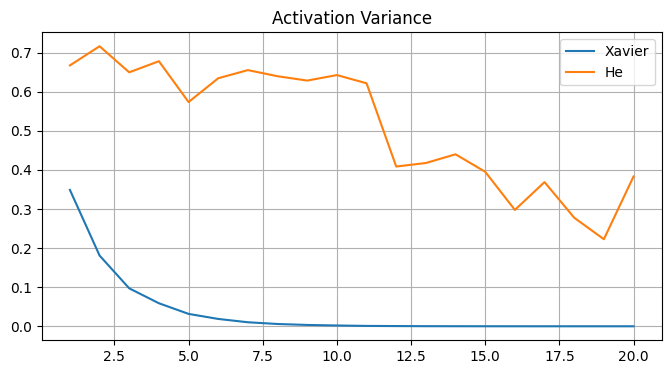

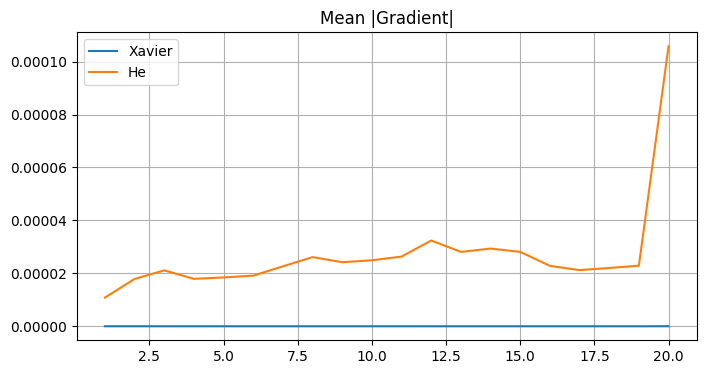

In [5]:
layers=np.arange(1,21)
plt.figure(figsize=(8,4));plt.plot(layers,xv,label='Xavier');plt.plot(layers,hv,label='He');plt.title('Activation Variance');plt.legend();plt.grid();plt.show()
plt.figure(figsize=(8,4));plt.plot(layers,xg,label='Xavier');plt.plot(layers,hg,label='He');plt.title('Mean |Gradient|');plt.legend();plt.grid();plt.show()